In [9]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
import json
import shap

from sklearn import manifold
from sklearn.metrics import accuracy_score

from bokeh.io import output_notebook, show, output_file
from bokeh.plotting import figure
from bokeh.models import GeoJSONDataSource, LinearColorMapper, ColorBar
from bokeh.palettes import brewer

import plotly.express as px
import plotly.graph_objs as go

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv('/content/dating_app_behavior_dataset.csv')
display(df.head())

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


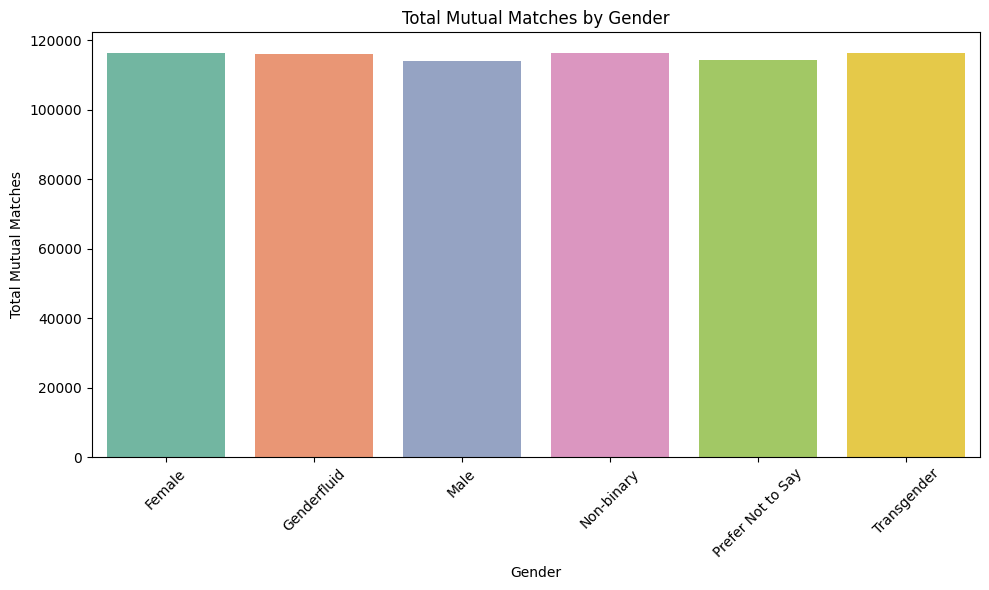

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Matches by Gender
plt.figure(figsize=(10, 6))
sns.barplot(x='gender', y='mutual_matches', data=df.groupby('gender')['mutual_matches'].sum().reset_index(), palette='Set2')
plt.title('Total Mutual Matches by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Mutual Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

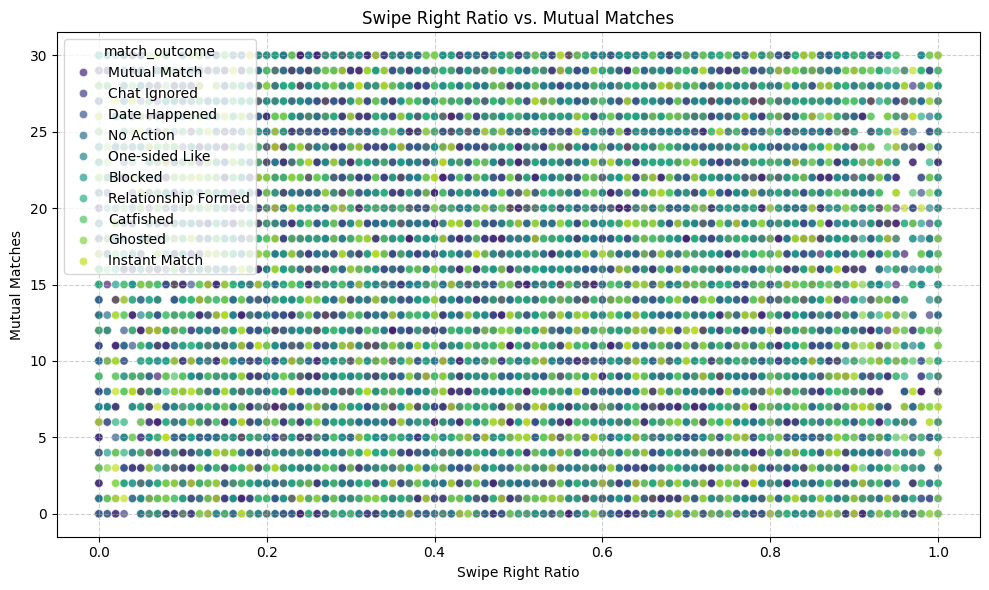

In [12]:
# Plot 2: Swipe vs Match Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='swipe_right_ratio', y='mutual_matches', data=df, hue='match_outcome', palette='viridis', alpha=0.7)
plt.title('Swipe Right Ratio vs. Mutual Matches')
plt.xlabel('Swipe Right Ratio')
plt.ylabel('Mutual Matches')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

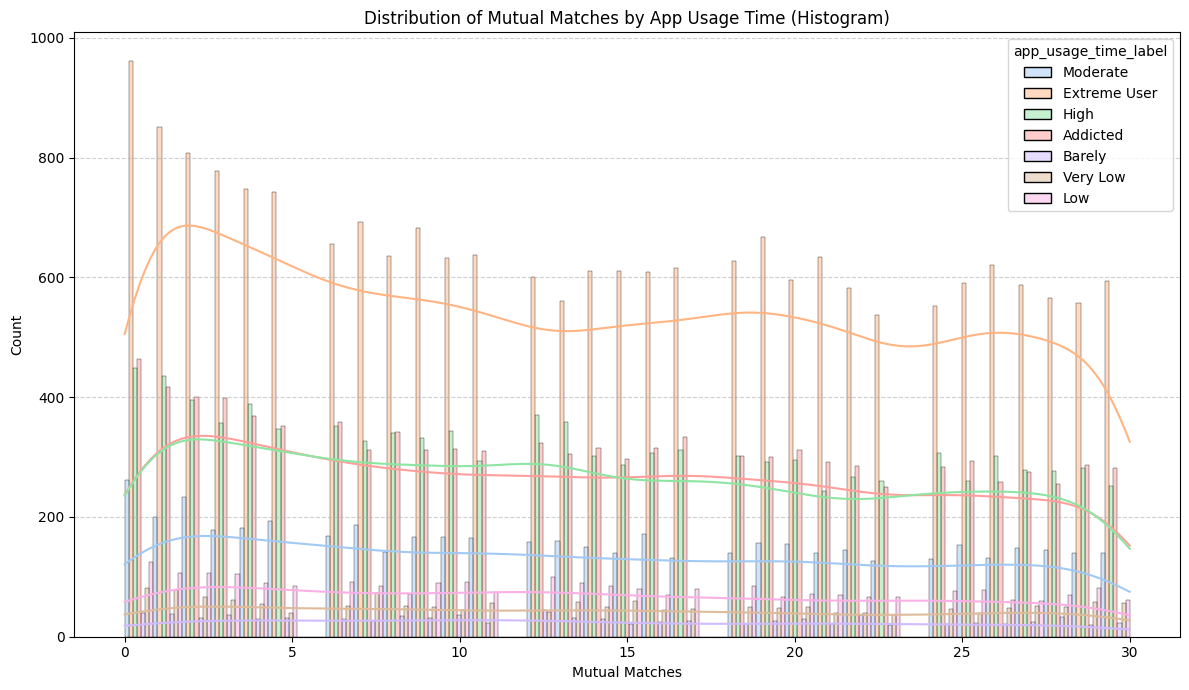

In [13]:
# Plot: Distribution of Mutual Matches by App Usage Time Label (Histogram)
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='mutual_matches', hue='app_usage_time_label', multiple='dodge', kde=True, palette='pastel')
plt.title('Distribution of Mutual Matches by App Usage Time (Histogram)')
plt.xlabel('Mutual Matches')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [14]:
# Example features (adjust to your dataset based on available columns)

# Total interactions (using message_sent_count and likes_received as proxies)
df['Total_Interactions'] = df['message_sent_count'] + df['likes_received']

# Match rate: Cannot be directly calculated as 'swipes' column (total swipes made) is missing.
# df['Match_Rate'] = df['mutual_matches'] / df['swipes']

# Engagement score (using message_sent_count as proxy, as messages_received is missing)
df['Engagement_Score'] = df['message_sent_count']

In [15]:
print('Mean Engagement_Score:', df['Engagement_Score'].mean())
print('Standard Deviation Engagement_Score:', df['Engagement_Score'].std())

print('\nMean Total_Interactions:', df['Total_Interactions'].mean())
print('Standard Deviation Total_Interactions:', df['Total_Interactions'].std())

Mean Engagement_Score: 50.07194
Standard Deviation Engagement_Score: 29.167999932816894

Mean Total_Interactions: 149.59798
Standard Deviation Total_Interactions: 64.89042468087194


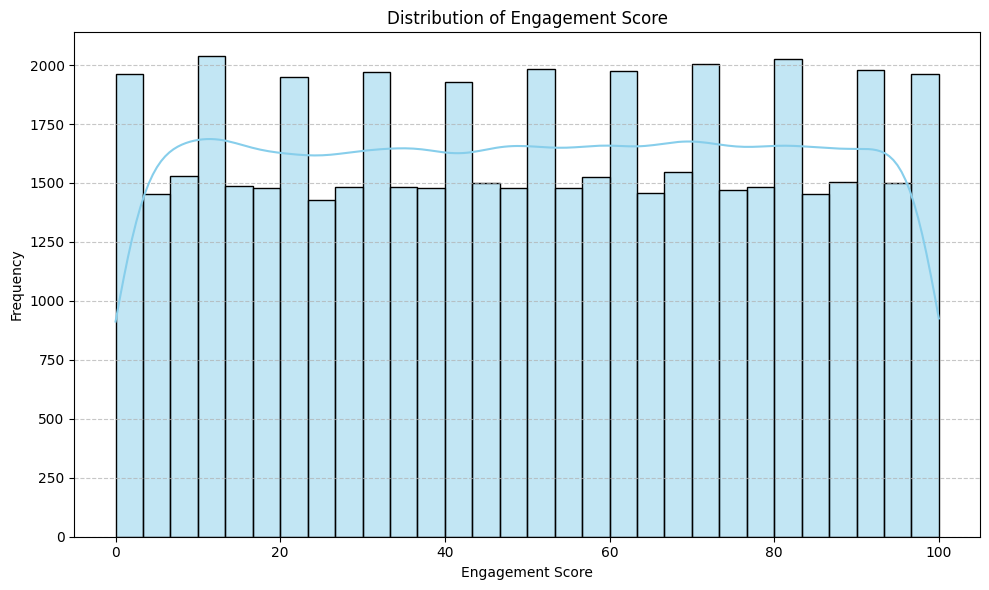

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Engagement_Score'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Engagement Score')
plt.xlabel('Engagement Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

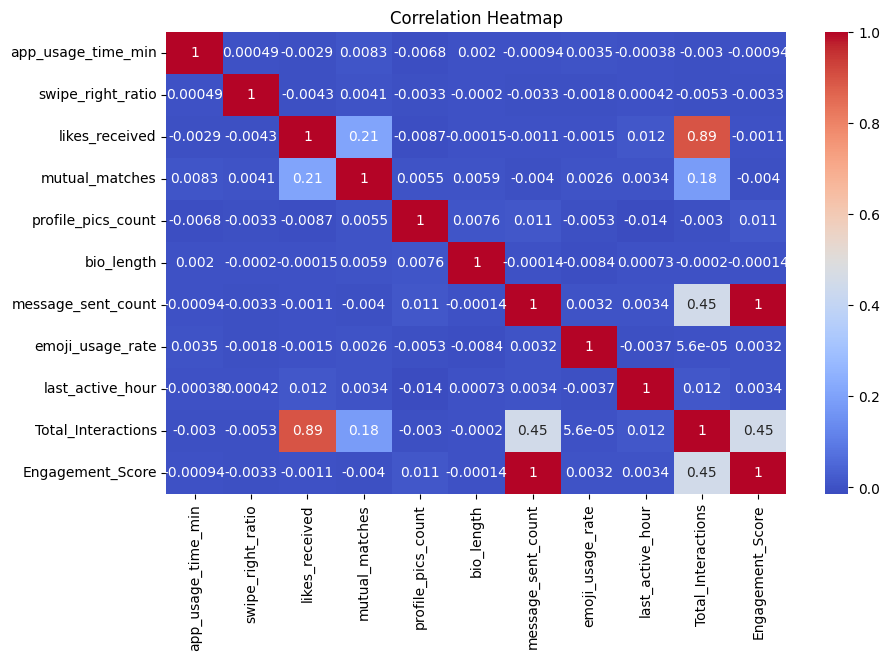

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
# Try to detect important columns
columns = df.columns

def find_col(possible_names):
    for name in possible_names:
        for col in columns:
            if name.lower() in col.lower():
                return col
    return None

swipes_col = find_col(['swipe'])
likes_col = find_col(['like'])
matches_col = find_col(['match'])
messages_sent_col = find_col(['message_sent','messages_sent'])
messages_received_col = find_col(['message_received','messages_received'])
gender_col = find_col(['gender'])
age_col = find_col(['age'])

In [19]:
# Total interactions
if swipes_col and likes_col:
    df['Total_Interactions'] = df[swipes_col] + df[likes_col]

# Match rate
if matches_col and swipes_col:
    df['Match_Rate'] = df[matches_col] / df[swipes_col]

# Engagement score
if messages_sent_col and messages_received_col:
    df['Engagement_Score'] = df[messages_sent_col] + df[messages_received_col]

# Selectiveness
if likes_col and swipes_col:
    df['Selectiveness'] = df[likes_col] / df[swipes_col]

In [20]:
if matches_col:
    df['High_Match_User'] = (df[matches_col] > df[matches_col].median()).astype(int)

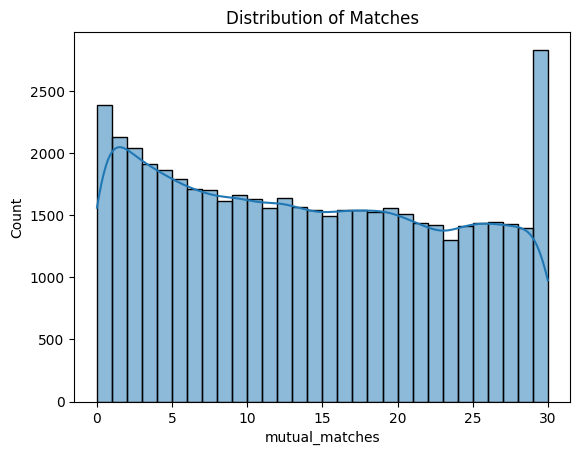

In [21]:
if matches_col:
    sns.histplot(df[matches_col], bins=30, kde=True)
    plt.title("Distribution of Matches")
    plt.show()

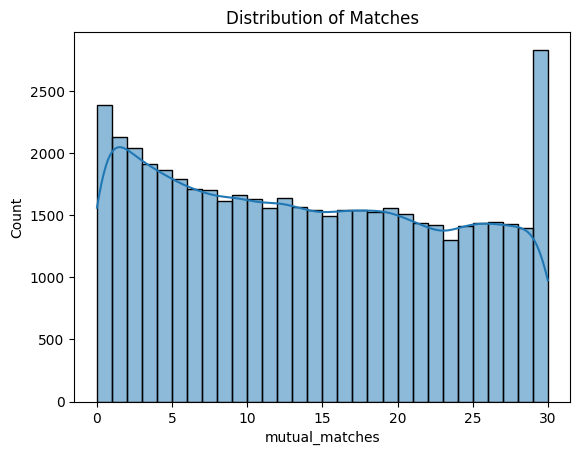

In [22]:
if matches_col:
    sns.histplot(df[matches_col], bins=30, kde=True)
    plt.title("Distribution of Matches")
    plt.show()

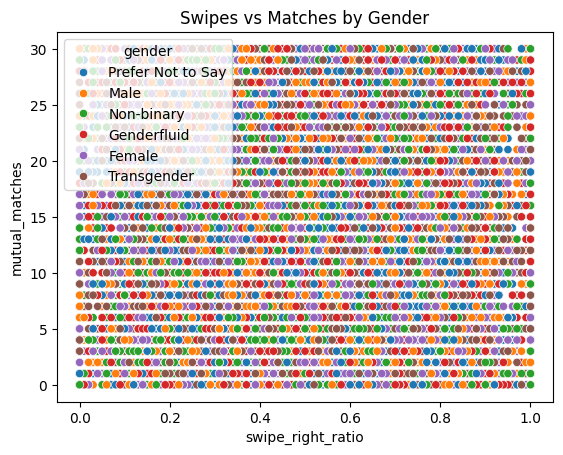

In [23]:
if swipes_col and matches_col and gender_col:
    sns.scatterplot(data=df, x=swipes_col, y=matches_col, hue=gender_col)
    plt.title("Swipes vs Matches by Gender")
    plt.show()
elif swipes_col and matches_col:
    sns.scatterplot(data=df, x=swipes_col, y=matches_col)
    plt.title("Swipes vs Matches")
    plt.show()

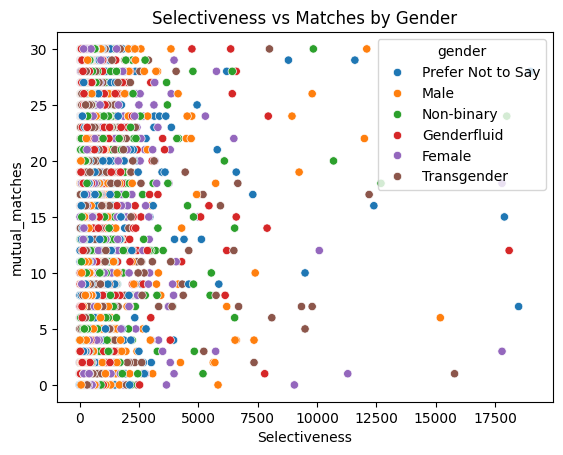

In [24]:
if 'Selectiveness' in df.columns and matches_col and gender_col:
    sns.scatterplot(data=df, x='Selectiveness', y=matches_col, hue=gender_col)
    plt.title("Selectiveness vs Matches by Gender")
    plt.show()
elif 'Selectiveness' in df.columns and matches_col:
    sns.scatterplot(data=df, x='Selectiveness', y=matches_col)
    plt.title("Selectiveness vs Matches")
    plt.show()

In [25]:
if 'Match_Rate' in df.columns and gender_col:
    # Replace infinite values with NaN before calculating the mean
    df_temp = df.copy()
    df_temp['Match_Rate'] = df_temp['Match_Rate'].replace([float('inf'), -float('inf')], pd.NA)
    avg_match_rate_by_gender = df_temp.groupby(gender_col)['Match_Rate'].mean().reset_index()
    print('Average Match Rate by Gender:')
    display(avg_match_rate_by_gender)
else:
    print("Could not calculate average Match Rate by gender. 'Match_Rate' or 'gender' column not found.")

Average Match Rate by Gender:


,gender,Match_Rate
0,Female,37.221154
1,Genderfluid,37.1467
2,Male,36.942244
3,Non-binary,37.315815
4,Prefer Not to Say,37.119311
5,Transgender,36.651578


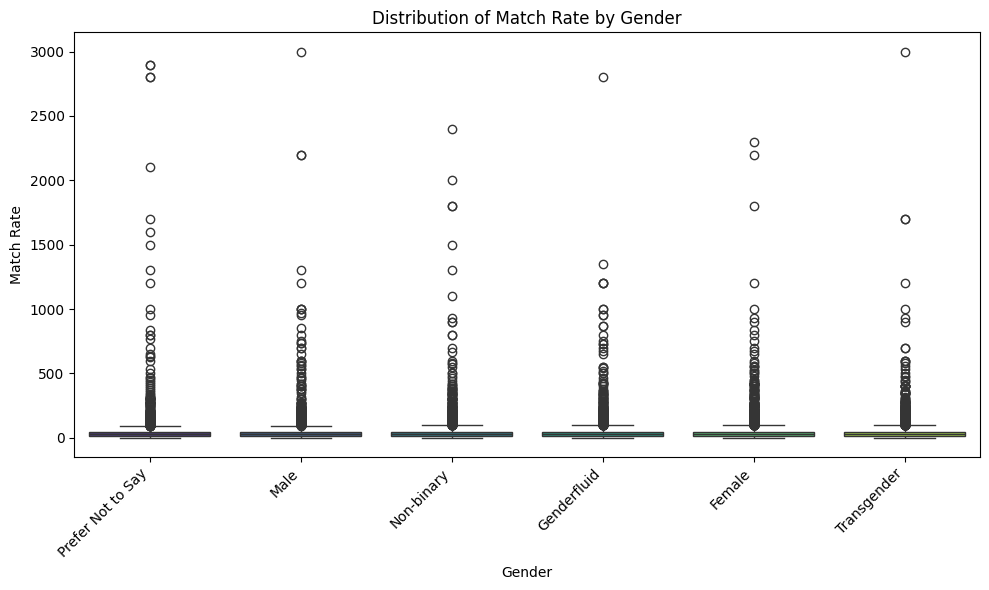

In [26]:
if 'Match_Rate' in df.columns and gender_col:
    # Replace infinite values with NaN for plotting
    df_plot = df.copy()
    df_plot['Match_Rate'] = df_plot['Match_Rate'].replace([float('inf'), -float('inf')], pd.NA)

    plt.figure(figsize=(10, 6))
    sns.boxplot(x=gender_col, y='Match_Rate', hue=gender_col, data=df_plot, palette='viridis')
    plt.title('Distribution of Match Rate by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Match Rate')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: 'Match_Rate' or 'gender' column not found.")

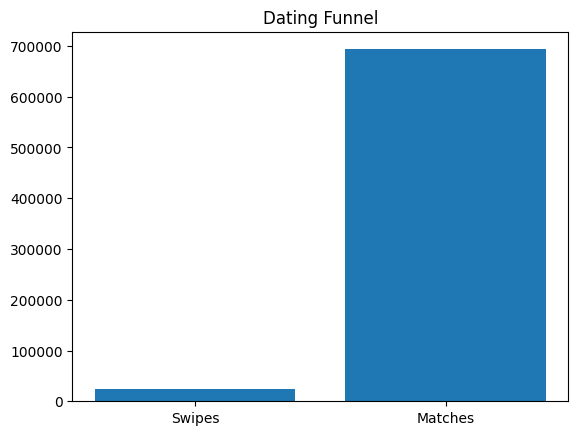

In [27]:
if swipes_col and matches_col:
    funnel = [
        df[swipes_col].sum(),
        df[matches_col].sum()
    ]

    stages = ['Swipes', 'Matches']

    plt.bar(stages, funnel)
    plt.title("Dating Funnel")
    plt.show()

In [28]:
if swipes_col and matches_col:
    total_swipes = df[swipes_col].sum()
    total_matches = df[matches_col].sum()

    if total_swipes > 0:
        conversion_rate = (total_matches / total_swipes) * 100
        print(f"Conversion Rate from Swipes to Matches: {conversion_rate:.2f}%")
    else:
        print("Cannot calculate conversion rate: Total swipes is zero.")
else:
    print("Cannot calculate conversion rate: 'swipe_right_ratio' or 'mutual_matches' column not found.")

Conversion Rate from Swipes to Matches: 2770.42%


In [29]:
from sklearn.model_selection import train_test_split

features = []

for col in ['Total_Interactions', 'Engagement_Score', 'Selectiveness']:
    if col in df.columns:
        features.append(col)

# fallback if needed
if not features:
    features = df.select_dtypes(include=np.number).columns.tolist()

X = df[features]
y = df['High_Match_User']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

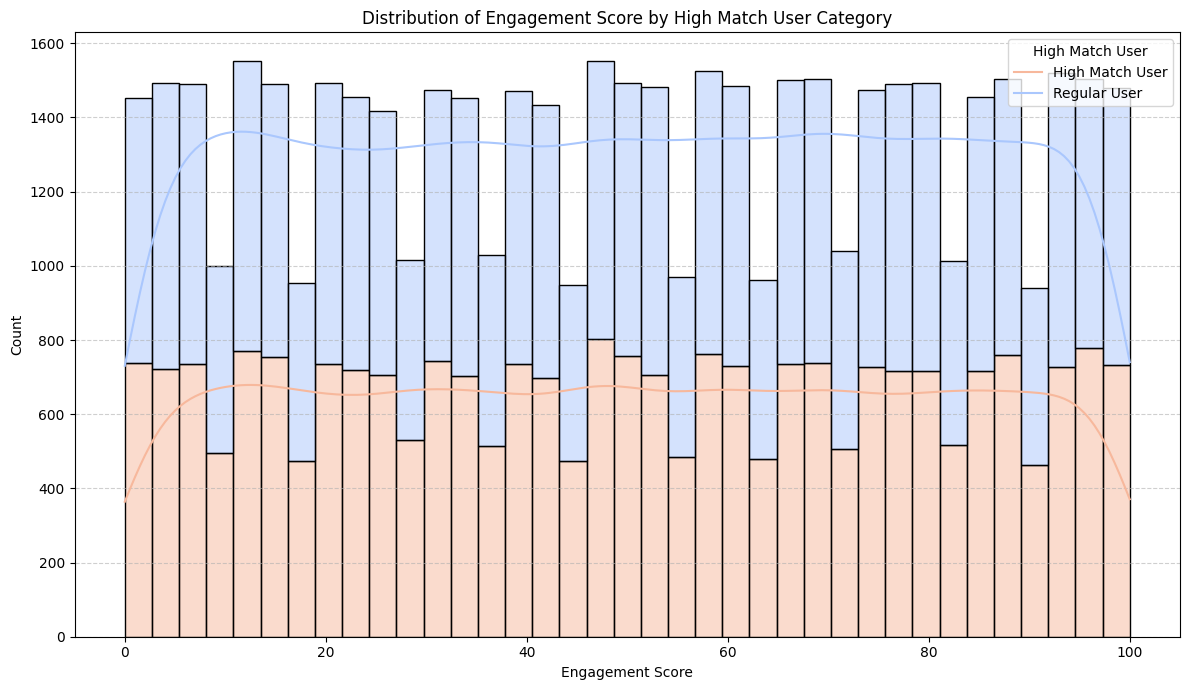

In [30]:
if 'Engagement_Score' in df.columns and 'High_Match_User' in df.columns:
    plt.figure(figsize=(12, 7))
    sns.histplot(data=df, x='Engagement_Score', hue='High_Match_User', multiple='stack', kde=True, palette='coolwarm')
    plt.title('Distribution of Engagement Score by High Match User Category')
    plt.xlabel('Engagement Score')
    plt.ylabel('Count')
    plt.legend(title='High Match User', labels=['High Match User', 'Regular User'])
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot create plot: 'Engagement_Score' or 'High_Match_User' column not found.")

In [31]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Handle infinite values in X_train and X_test
# Replace infinite values with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute NaN values with the mean of their respective columns
# It's important to fit the imputer only on X_train and transform both X_train and X_test
for col in X_train.columns:
    if X_train[col].isnull().any():
        mean_value = X_train[col].mean()
        X_train[col].fillna(mean_value, inplace=True)
        # Use the mean from the training set to fill NaNs in the test set to prevent data leakage
        X_test[col].fillna(mean_value, inplace=True)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
from sklearn.metrics import classification_report, accuracy_score

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.5553
              precision    recall  f1-score   support

           0       0.57      0.52      0.54      5069
           1       0.54      0.59      0.57      4931

    accuracy                           0.56     10000
   macro avg       0.56      0.56      0.55     10000
weighted avg       0.56      0.56      0.55     10000



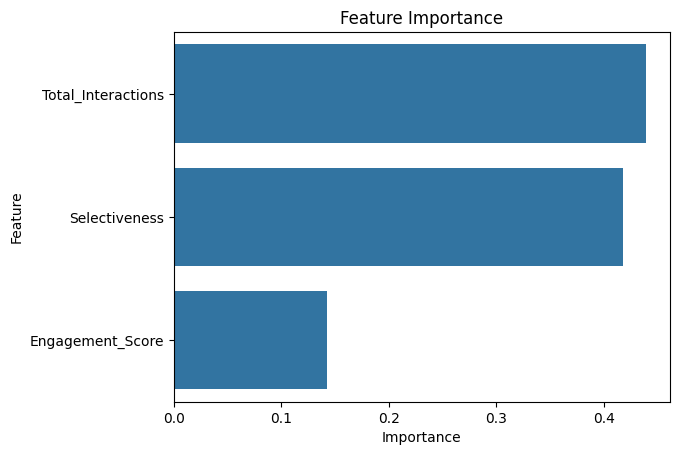

In [34]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(data=importance, x='Importance', y='Feature')
plt.title("Feature Importance")
plt.show()

In [35]:
if swipes_col and matches_col:
    fig = px.scatter(
        df,
        x=swipes_col,
        y=matches_col,
        color=gender_col if gender_col else None,
        size='Engagement_Score' if 'Engagement_Score' in df.columns else None,
        title="Dating Behavior Analysis"
    )
    fig.show()

In [36]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [37]:
%whos

Variable                     Type                      Data/Info
----------------------------------------------------------------
ColorBar                     MetaHasProps              <class 'bokeh.models.anno<...>ations.legends.ColorBar'>
GeoJSONDataSource            MetaHasProps              <class 'bokeh.models.sources.GeoJSONDataSource'>
GradientBoostingClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
KMeans                       ABCMeta                   <class 'sklearn.cluster._kmeans.KMeans'>
LabelEncoder                 type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LinearColorMapper            MetaHasProps              <class 'bokeh.models.mappers.LinearColorMapper'>
LogisticRegression           type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
PCA                          ABCMeta                   <class 'sklearn.decomposition._pca.PCA'>
RandomForestClassifier    

In [38]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [39]:
from sklearn.metrics import accuracy_score

rf_preds = model.predict(X_test)
log_preds = log_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))

Random Forest Accuracy: 0.5553
Logistic Regression Accuracy: 0.5516


In [40]:
from sklearn.metrics import classification_report

print("Random Forest Report:\n", classification_report(y_test, rf_preds))
print("Logistic Regression Report:\n", classification_report(y_test, log_preds))

Random Forest Report:
               precision    recall  f1-score   support

           0       0.57      0.52      0.54      5069
           1       0.54      0.59      0.57      4931

    accuracy                           0.56     10000
   macro avg       0.56      0.56      0.55     10000
weighted avg       0.56      0.56      0.55     10000

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.56      0.56      0.56      5069
           1       0.55      0.54      0.54      4931

    accuracy                           0.55     10000
   macro avg       0.55      0.55      0.55     10000
weighted avg       0.55      0.55      0.55     10000



In [41]:
from sklearn.cluster import KMeans
import numpy as np

cluster_features = X.copy()

# Handle infinite values (replace with NaN first for consistent imputation)
cluster_features.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute NaN values with the mean of their respective columns
for col in cluster_features.columns:
    if cluster_features[col].isnull().any():
        mean_value = cluster_features[col].mean()
        cluster_features[col].fillna(mean_value, inplace=True)

kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['User_Type'] = kmeans.fit_predict(cluster_features)

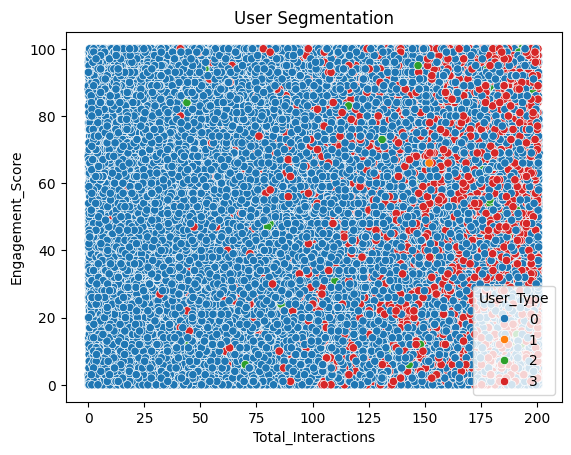

In [42]:
sns.scatterplot(
    data=df,
    x=features[0],
    y=features[1],
    hue='User_Type',
    palette='tab10'
)
plt.title("User Segmentation")
plt.show()

In [43]:
cluster_summary = df.groupby('User_Type')[features].mean()
print(cluster_summary)

           Total_Interactions  Engagement_Score  Selectiveness
User_Type                                                     
0                   90.050035         50.004896            inf
1                  151.012500         53.428571   1.275179e+04
2                  142.598765         49.588477   3.749903e+03
3                  155.081817         50.455693   6.333182e+02


In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

In [45]:
rf_probs = model.predict_proba(X_test)[:,1]
log_probs = log_model.predict_proba(X_test)[:,1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)

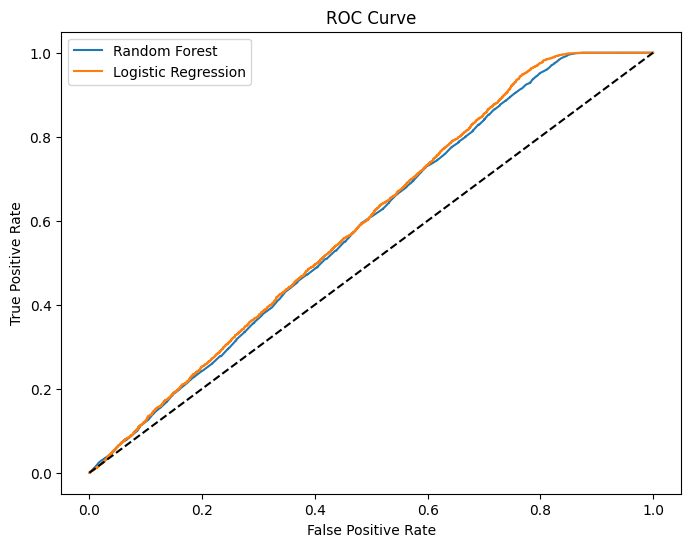

In [46]:
plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(log_fpr, log_tpr, label="Logistic Regression")

plt.plot([0,1],[0,1],'k--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [47]:
rf_auc = roc_auc_score(y_test, rf_probs)
log_auc = roc_auc_score(y_test, log_probs)

print("Random Forest AUC:", rf_auc)
print("Logistic Regression AUC:", log_auc)

Random Forest AUC: 0.5858693929671966
Logistic Regression AUC: 0.5934356938935451


In [48]:
!pip install xgboost

In [49]:
from xgboost import XGBClassifier

In [50]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [51]:
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))

XGBoost Accuracy: 0.583


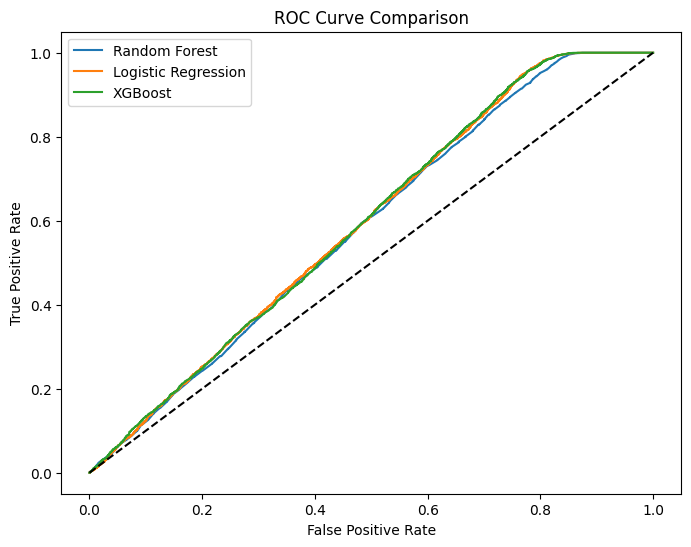

In [52]:
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [53]:
xgb_auc = roc_auc_score(y_test, xgb_probs)

print("Random Forest AUC:", rf_auc)
print("Logistic Regression AUC:", log_auc)
print("XGBoost AUC:", xgb_auc)

Random Forest AUC: 0.5858693929671966
Logistic Regression AUC: 0.5934356938935451
XGBoost AUC: 0.5939773970554952


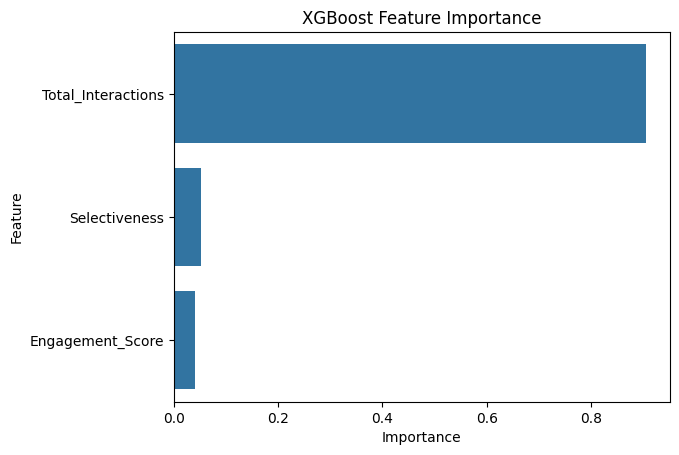

In [54]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(data=importance, x='Importance', y='Feature')
plt.title("XGBoost Feature Importance")
plt.show()